# Minnesota Case Study – User Cost and IRI Analysis
**Paper:** *Impact of Integrating Use Stage into Network Level Life Cycle Planning*  

This notebook reproduces the Minnesota case study results (Figs. 3–7 in the paper):
- RQI and SR trends (Fig. 3)
- Weighted average IRI trend (Fig. 4)
- Treatment distribution by year (Fig. 5)
- User costs by vehicle type (Fig. 6)
- Agency costs from MnDOT CHIP program (Fig. 7)

**Data source:** MnDOT CHIP dataset (provided by MnDOT for research purposes).  
Update the file paths to point to your local copies of the data files.

## 1. Imports, Data Loading, and Setup

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the path to your data
# Update the path if the folder name or file name is slightly different
file_path = "mndot_dummy.xlsx"

# Read the "CHIP" sheet from the Excel file
df = pd.read_excel(file_path, sheet_name="CHIP")

# Preview the dataframe
df.head()

# Filter the DataFrame to include only specific pavement types
used_pavement_types = ['BAB', 'BFD', 'BOB', 'BOC']
filtered_df = df[df['Pvmt_Type'].isin(used_pavement_types)].copy()  # Copy to avoid modifying the original

# Iterate over the RQI columns and compute corresponding IRI values for the filtered data
for year in range(2024, 2036):  # From 2024 to 2035
    rqi_col = f'RQI_{year}'
    iri_col = f'IRI_{year}_Calculated'

    # Compute IRI using the given formula
    filtered_df[iri_col] = ((5.697 - filtered_df[rqi_col]) / 0.264) ** 2

# Display the first few rows of the filtered DataFrame to verify
print(filtered_df[[col for col in filtered_df.columns if 'RQI' in col or 'IRI' in col]].head())
# Define the speed limits for each functional class they are in mph
speed_limits = {
    "Local": 30,
    "Major Collector": 55,
    "Minor Collector": 55,
    "Minor Arterial": 55,
    "Princ. Arterial": 55,
    "Princ. Art. Freeway": 65,
    "Interstate": 70
}

# Create a new "Speed" column based on "Funct_Class"
filtered_df["Speed"] = filtered_df["Funct_Class"].map(speed_limits)

#MJ per gallon
fuel_conversion_rates = {
    'Passenger_Vehicle': 126.9,
    'Small_Truck': 126.9,
    'Medium_Truck': 145,
    'Large_Truck': 145
}
energy_coefficients = {
    'Passenger_Vehicle': {'ka': 0.67, 'kc': 0.000281, 'dc': 0.2186, 'da': 2175.7, 'b': -16.931, 'p': 33753},
    'Small_Truck': {'ka': 0.768, 'kc': 0.000125, 'dc': 0.30769, 'da': 7010.8, 'b': -73.026, 'p': 117880},
    'Medium_Truck': {'ka': 0.918, 'kc': 0.000133, 'dc': 0.97418, 'da': 9299.3, 'b': -139.58, 'p': 109380},
    'Large_Truck': {'ka': 1.4, 'kc': 0.000136, 'dc': 2.39, 'da': 19225, 'b': -264.32, 'p': 82782}
}
#assumption can be changed
vehicle_percentages = {
    'Passenger_Vehicle': 0.70,
    'Small_Truck': 0.10,
    'Medium_Truck': 0.15,
    'Large_Truck': 0.05
}

annual_traffic_growth = 0.00
# Initialize AADT for the first year (directly from filtered_df["AADT"])
filtered_df["AADT_2024"] = filtered_df["AADT"]

# Calculate AADT for subsequent years using the growth rate
for year in range(2025, 2036):  # From 2025 to 2035
    prev_year = year - 1
    filtered_df[f"AADT_{year}"] = filtered_df[f"AADT_{prev_year}"] * (1 + annual_traffic_growth)

# Compute AvgIRI_{year}_year values dynamically using IRI_{year}_Calculated
filtered_df["AvgIRI_2024_year"] = filtered_df["IRI_2024_Calculated"]

for year in range(2025, 2036):  # From 2025 to 2035
    prev_year = year - 1
    avg_iri_column = f"AvgIRI_{year}_year"

    # Use IRI_{year}_Calculated instead of the missing "IRI_after_{year}_y"
    filtered_df[avg_iri_column] = (filtered_df[f"AvgIRI_{prev_year}_year"] + filtered_df[f"IRI_{year}_Calculated"]) / 2

# Shortened vehicle type names
vehicle_names = {
    "Passenger_Vehicle": "Passenger Vehicle",
    "Small_Truck": "Small Truck",
    "Medium_Truck": "Medium Truck",
    "Large_Truck": "Large Truck"
}
# Define base IRI (if not defined elsewhere)
# Base IRI = 20 in/mi: minimum observed IRI in the MnDOT dataset (0.32 m/km).
# Only excess fuel consumption above this baseline is counted as user cost.
base_iri = 20
def calculate_energy(vehicle_type, avg_iri_column, base_iri, filtered_df):

    # Get the energy coefficients for the vehicle type
    coeffs = energy_coefficients[vehicle_type]

    # Extract energy coefficients
    ka, kc, dc, da, b, p = coeffs['ka'], coeffs['kc'], coeffs['dc'], coeffs['da'], coeffs['b'], coeffs['p']

    # Compute energy_base (MJ) using base IRI
    energy_base = (
        (p / filtered_df["Speed"]) +
        (ka * base_iri + da) +
        (b * filtered_df["Speed"]) +
        (((kc * base_iri) + dc) * (filtered_df["Speed"] ** 2))
    ) / 1000  # Convert from kJ to MJ

    # Compute energy_actual (MJ) using the IRI values from the given column
    energy_actual = (
        (p / filtered_df["Speed"]) +
        (ka * filtered_df[avg_iri_column] + da) +
        (b * filtered_df["Speed"]) +
        (((kc * filtered_df[avg_iri_column]) + dc) * (filtered_df["Speed"] ** 2))
    ) / 1000  # Convert from kJ to MJ

    # Return differential energy (MJ)
    return energy_actual - energy_base

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    RQI_2024  RQI_2025  RQI_2026  RQI_2027  RQI_2028  RQI_2029  RQI_2030  \
2        4.2       4.1       4.0       3.9       3.8       3.7       3.6   
3        3.8       3.7       3.6       3.5       3.4       3.3       3.2   
6        3.2       3.1       3.0       2.9       2.9       2.8       2.7   
7        3.4       3.8       3.7       3.7       3.7       3.7       3.7   
20       3.9       3.8       3.7       3.7       3.6       3.5       3.4   

    RQI_2031  RQI_2032  RQI_2033  ...  IRI_2026_Calculated  \
2        3.5       3.4       3.3  ...            41.319574   
3        3.1       3.8       3.7  ...            63.094137   
6        3.8       3.7       3.6  ...           104.364799   
7        3.6       3.6       3.6  ...            57.220056   
20       3.3       3.2       3.1  ...            57.220056   

    IRI_2027_Calculated  IRI_2028_Calcula

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


## 2. Weighted Average IRI (2024–2035)

Lane-mile weighted average IRI across the network for each year. The minimum IRI in the dataset (20 in/mi = 0.32 m/km) is used as the user cost baseline.

In [ ]:
# Calculate weighted average IRI per year using Lane_Miles as weights
weighted_avg_iri_per_year = {}

for year in range(2024, 2036):  # From 2024 to 2035
    iri_col = f"IRI_{year}_Calculated"
    weights = filtered_df["Lane_Miles"]
    # Avoid division by zero
    if weights.sum() > 0:
        weighted_avg_iri = (filtered_df[iri_col] * weights).sum() / weights.sum()
    else:
        weighted_avg_iri = None

    weighted_avg_iri_per_year[year] = weighted_avg_iri

# Convert the result into a DataFrame
weighted_iri_df = pd.DataFrame.from_dict(weighted_avg_iri_per_year, orient='index', columns=["Weighted_Avg_IRI"])
weighted_iri_df.index.name = "Year"

# Print the result
print(weighted_iri_df)
# Find the minimum IRI value across all years
iri_columns = [f"IRI_{year}_Calculated" for year in range(2024, 2036)]
min_iri = filtered_df[iri_columns].min().min()  # Find the minimum across all columns

print(f"Minimum IRI value: {min_iri}")

      Weighted_Avg_IRI
Year                  
2024         79.091549
2025         82.220561
2026         86.552875
2027         91.103122
2028         96.999084
2029        101.007205
2030        104.928253
2031        109.447070
2032        112.492673
2033        114.511983
2034        118.236311
2035        126.410166
Minimum IRI value: 20.55798037190083


## 3. Plot Theme Settings

In [ ]:
# Theme settings
sns.set_theme(
    style="darkgrid",
    font_scale=1.6,
    rc={
        "figure.figsize": (12, 7),
        "axes.labelsize": 20,
        "axes.labelweight": "bold",
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 20,
        "legend.title_fontsize": 20
    }
)

plt.rcParams["figure.dpi"] = 120

## 4. Weighted Average IRI Trend – Fig. 4

Lane-mile weighted average IRI (m/km) over the analysis period.

      Avg_IRI
Year         
2025   1.2974
2026   1.3658
2027   1.4376
2028   1.5306
2029   1.5939
2030   1.6558
2031   1.7271
2032   1.7751
2033   1.8070
2034   1.8658


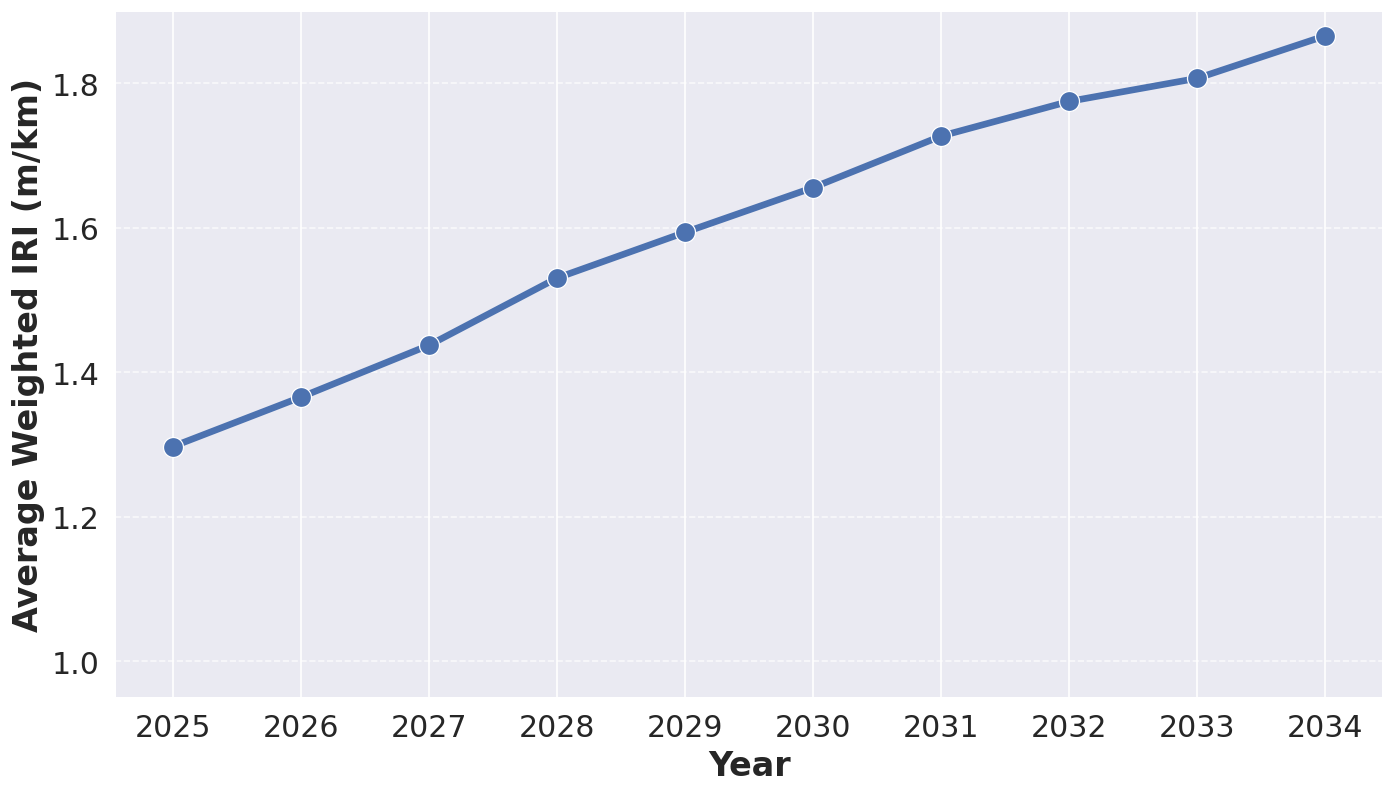

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate weighted average IRI per year using Lane_Miles as weights
weighted_avg_iri_per_year = {}

for year in range(2025, 2035):  # From 2025 to 2034
    iri_col = f"IRI_{year}_Calculated"
    weights = filtered_df["Lane_Miles"] / filtered_df["Lane_Miles"].sum()

    # Avoid division by zero
    if weights.sum() > 0:
        weighted_avg_iri = (filtered_df[iri_col] * weights).sum() / weights.sum()
    else:
        weighted_avg_iri = None

    # Convert from in/mi to m/km (× 0.01578)
    if weighted_avg_iri is not None:
        weighted_avg_iri = weighted_avg_iri * 0.01578

    weighted_avg_iri_per_year[year] = weighted_avg_iri

# Convert the result into a DataFrame
weighted_iri_df = pd.DataFrame.from_dict(weighted_avg_iri_per_year, orient='index', columns=["Avg_IRI"])
weighted_iri_df.index.name = "Year"

# Round to 4 decimal places
weighted_iri_df = weighted_iri_df.round(4)

print(weighted_iri_df)

# --- Plot ---
plt.figure()
ax = sns.lineplot(
    x=weighted_iri_df.index,
    y=weighted_iri_df["Avg_IRI"],
    marker="o",
    markersize=12,
    linewidth=4
)

# y-axis limits in m/km (60-120 in/mi → 0.95-1.90 m/km)
ax.set_ylim(0.95, 1.90)

# Labels
ax.set_xlabel("Year", fontweight='bold')
ax.set_ylabel("Average Weighted IRI (m/km)", fontweight='bold')

ax.set_xticks(weighted_iri_df.index)
ax.set_xticklabels(weighted_iri_df.index, rotation=0)
ax.tick_params(axis="y")

# Keep only horizontal grid lines as dashed
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 5. RQI and SR Trends – Fig. 3

Lane-mile weighted average RQI and SR over the analysis period.

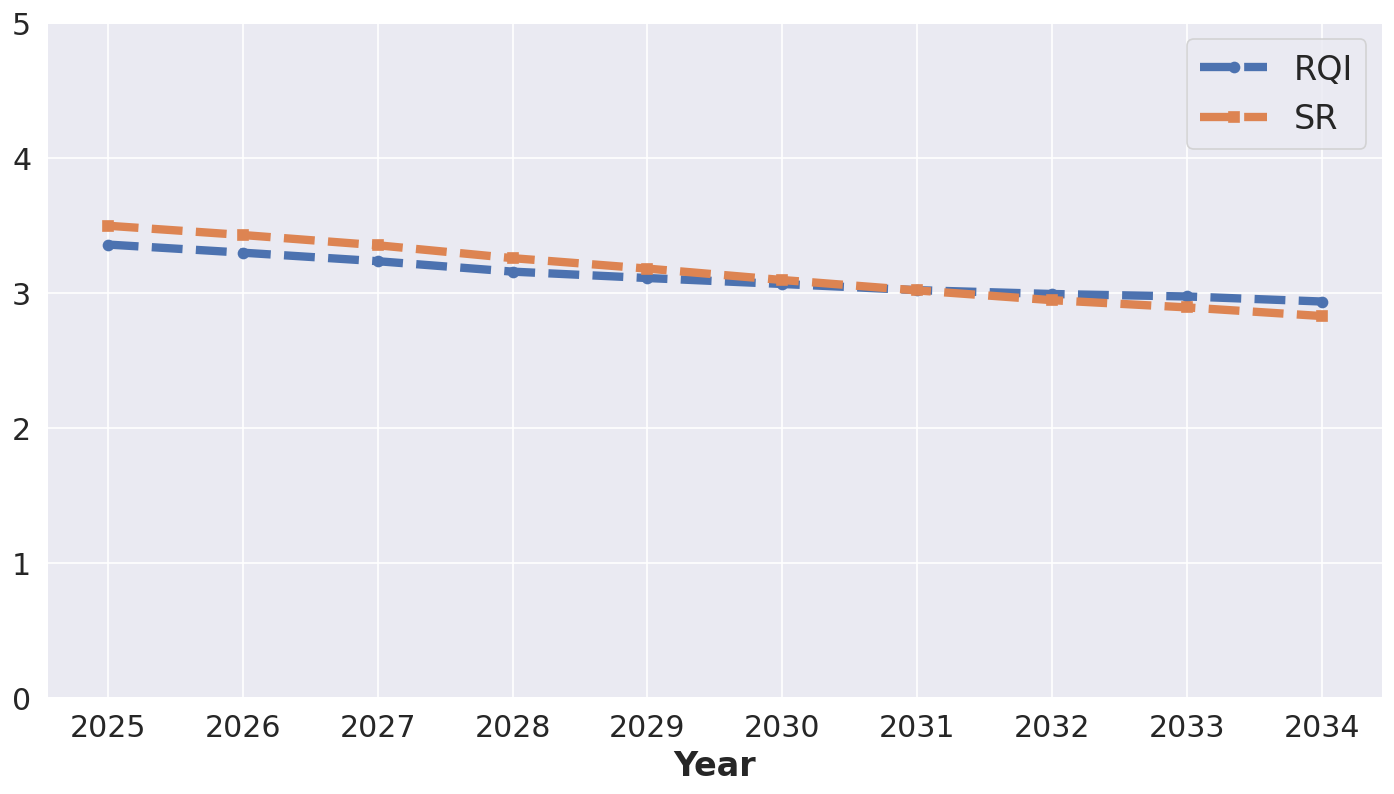

In [ ]:
weighted_avg_rqi_per_year = {}
weighted_avg_sr_per_year = {}

for year in range(2025, 2035):
    rqi_col = f"RQI_{year}"
    sr_col = f"SR_{year}"

    weights = filtered_df["Lane_Miles"]

    # Weighted RQI
    if rqi_col in filtered_df.columns and weights.sum() > 0:
        weighted_avg_rqi = (filtered_df[rqi_col] * weights).sum() / weights.sum()
    else:
        weighted_avg_rqi = None

    # Weighted SR
    if sr_col in filtered_df.columns and weights.sum() > 0:
        weighted_avg_sr = (filtered_df[sr_col] * weights).sum() / weights.sum()
    else:
        weighted_avg_sr = None

    weighted_avg_rqi_per_year[year] = weighted_avg_rqi
    weighted_avg_sr_per_year[year] = weighted_avg_sr

# Convert to DataFrames
weighted_rqi_df = pd.DataFrame.from_dict(weighted_avg_rqi_per_year, orient='index', columns=["Weighted_Avg_RQI"])
weighted_sr_df = pd.DataFrame.from_dict(weighted_avg_sr_per_year, orient='index', columns=["Weighted_Avg_SR"])

# Set index name
weighted_rqi_df.index.name = "Year"
weighted_sr_df.index.name = "Year"

# Optionally plot RQI and SR
plt.figure()
plt.plot(weighted_rqi_df.index, weighted_rqi_df["Weighted_Avg_RQI"], marker='o', linestyle='--', label="RQI", linewidth=5)
plt.plot(weighted_sr_df.index, weighted_sr_df["Weighted_Avg_SR"], marker='s', linestyle='--', label="SR", linewidth=5)
#plt.title("Yearly RQI and SR Change")
plt.ylim(0,5)
plt.xlabel("Year")
plt.ylabel("")
plt.legend()
plt.grid(True)
plt.xticks(weighted_rqi_df.index)
plt.tight_layout()
plt.show()

## 6. RQI Category Distribution (2025)

/tmp/ipykernel_3735/2641569257.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


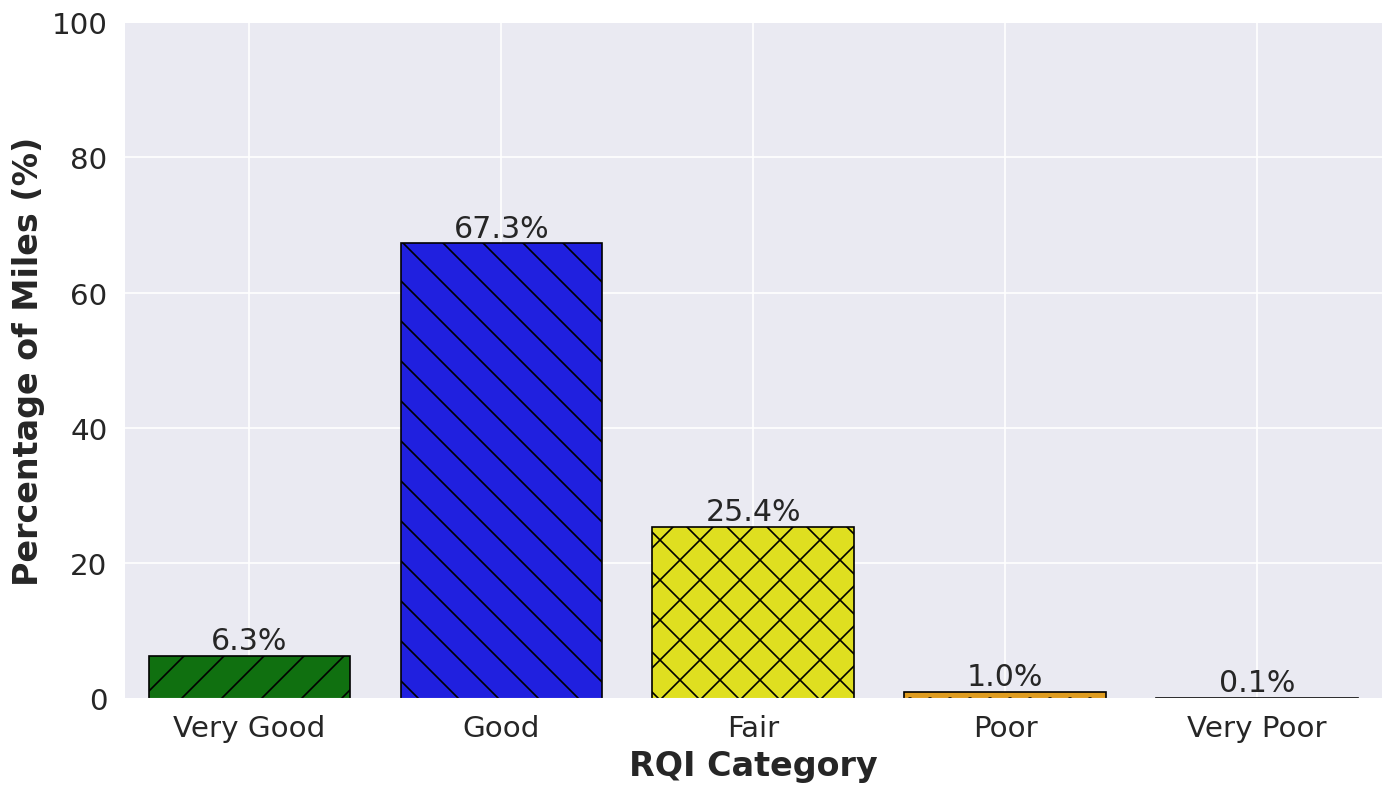

In [ ]:
# Define RQI categories and their ranges
rqi_categories = {
    "Very Good": (4.1, 5.0),
    "Good": (3.1, 4.0),
    "Fair": (2.1, 3.0),
    "Poor": (1.1, 2.0),
    "Very Poor": (0.0, 1.0)
}

category_percentages = {}
category_mile_totals = {}

total_lane_miles = filtered_df["Lengt_miles"].sum()

# Calculate weighted percentages
for category, (low, high) in rqi_categories.items():
    category_miles = filtered_df.loc[
        (filtered_df["RQI_2025"] >= low) & (filtered_df["RQI_2025"] <= high),
        "Lengt_miles"
    ].sum()
    category_mile_totals[category] = category_miles
    category_percentages[category] = (category_miles / total_lane_miles) * 100

# Convert to DataFrame
rqi_df = pd.DataFrame({
    "Category": list(category_percentages.keys()),
    "Percentage": list(category_percentages.values())
})
sns.set_theme(style="darkgrid", font_scale=1.6)

hatches = ['/', '\\', 'x', '.', 'o']
colors = ["green", "blue", "yellow", "orange", "red"]
fig, ax = plt.subplots(figsize=(12, 7))
bars = sns.barplot(
    data=rqi_df,
    x="Category",
    y="Percentage",
    palette=colors,
    edgecolor="black",
    ax=ax
)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i])

ax.set_ylim(0, 100)
ax.set_xlabel("RQI Category", fontsize=20, fontweight="bold")
ax.set_ylabel("Percentage of Miles (%)", fontsize=20, fontweight="bold")
ax.set_axisbelow(True)
ax.grid(True, axis="both")

for i, v in enumerate(rqi_df["Percentage"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=18)

plt.tight_layout()
plt.show()

## 7. SR Category Distribution (2025)

/tmp/ipykernel_3735/2193451501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


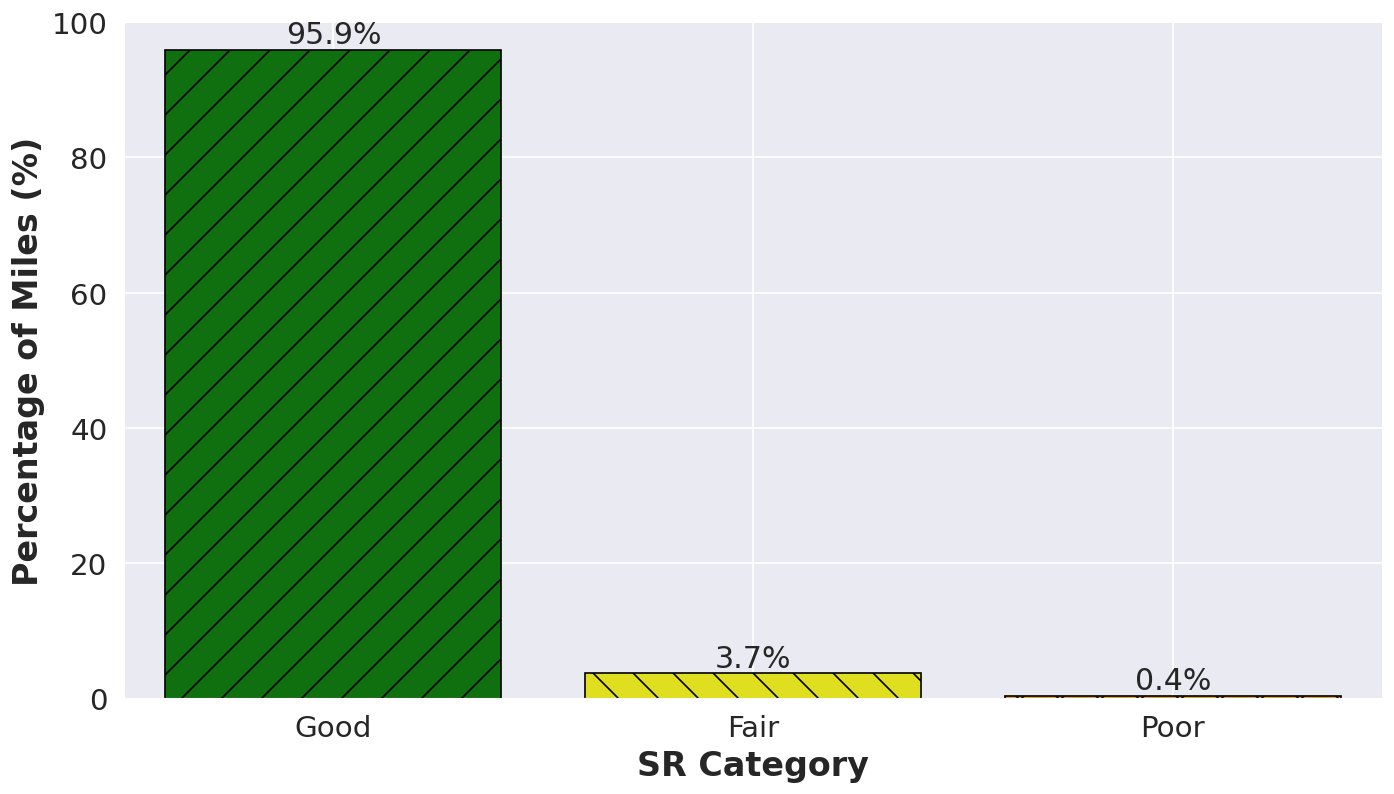

In [ ]:
sr_df = pd.DataFrame({
    "Category": ["Good", "Fair", "Poor"],
    "Percentage": [95.9, 3.7, 0.4]
})
sns.set_theme(style="darkgrid", font_scale=1.6)

hatches = ['/', '\\', 'x']
colors = ["green", "yellow", "orange"]

fig, ax = plt.subplots(figsize=(12, 7))
bars = sns.barplot(
    data=sr_df,
    x="Category",
    y="Percentage",
    palette=colors,
    edgecolor="black",
    ax=ax
)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i])

ax.set_ylim(0, 100)
ax.set_xlabel("SR Category", fontsize=20, fontweight="bold")
ax.set_ylabel("Percentage of Miles (%)", fontsize=20, fontweight="bold")
ax.set_axisbelow(True)
ax.grid(True, axis="both")

for i, v in enumerate(sr_df["Percentage"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=18)

plt.tight_layout()
plt.show()

## 8. Treatment Distribution by Year – Fig. 5

Percentage share of each treatment type per year. Total treated lane-km is annotated above each bar.

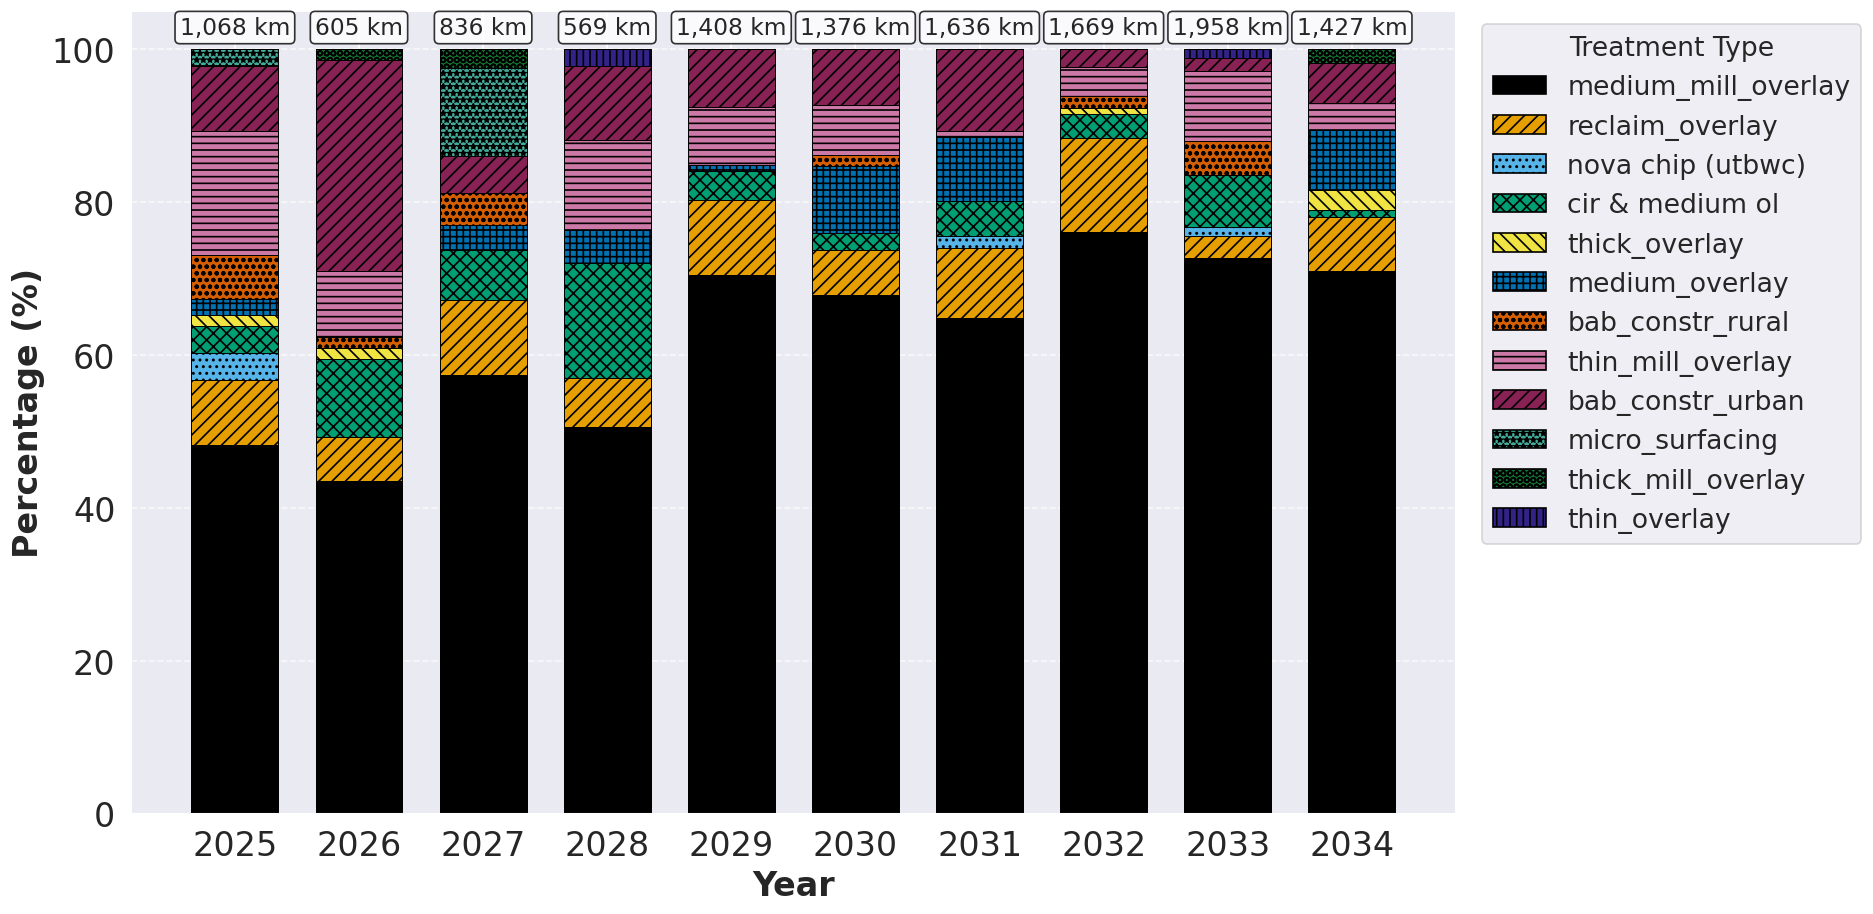

In [ ]:
import matplotlib.patches as mpatches

plot_df = filtered_df.copy()
plot_df["Planned_Work_Type"] = plot_df["Planned_Work_Type"].str.lower().str.strip()

# Get unique treatments, excluding concrete treatments
allowed_treatments = [
    t for t in plot_df['Planned_Work_Type'].dropna().unique()
    if t not in [None, 'nan', 'whitetop (undoweled)', 'whitetop (doweled)',
                 'cd constr - rural', 'cd constr - urban', 'unbonded_overlay']
]


plot_df = plot_df[plot_df['Planned_Work_Type'].isin(allowed_treatments)].copy()

# Calculate total lane miles treated per year
miles_per_year = plot_df.groupby("Planned_Work_Year")["Lane_Miles"].sum()

# --- Accessible color palette (WCAG-friendly, distinct under colorblindness) ---
accessible_colors = [
    "#000000",  # Black
    "#E69F00",  # Orange
    "#56B4E9",  # Sky Blue
    "#009E73",  # Bluish Green
    "#F0E442",  # Yellow
    "#0072B2",  # Blue
    "#D55E00",  # Vermillion
    "#CC79A7",  # Reddish Purple
    "#882255",  # Dark Maroon
    "#44AA99",  # Teal
    "#117733",  # Dark Green
    "#332288",  # Indigo
    "#DDCC77",  # Sand
    "#88CCEE",  # Light Blue
    "#AA4499",  # Purple
    "#999933",  # Olive
]

# --- Hatch patterns for pattern-based distinction ---
hatch_patterns = ['', '///', '...', 'xxx', '\\\\\\', '+++', 'ooo', '---',
                  '///', '***', 'OOO', '|||', '\\\\\\', '...', 'xxx', '+++']

# Trim to number of treatments
n = len(allowed_treatments)
colors = (accessible_colors * ((n // len(accessible_colors)) + 1))[:n]
hatches = (hatch_patterns * ((n // len(hatch_patterns)) + 1))[:n]

treatment_color_map = dict(zip(allowed_treatments, colors))
treatment_hatch_map = dict(zip(allowed_treatments, hatches))

# Group by year and treatment
treatment_counts_per_year = plot_df[
    plot_df["Planned_Work_Year"].between(2025, 2034)
].groupby(["Planned_Work_Year", "Planned_Work_Type"]).size().unstack(fill_value=0)

treatment_counts_per_year = treatment_counts_per_year.reindex(columns=allowed_treatments, fill_value=0)

total_treatments_per_year = treatment_counts_per_year.sum(axis=1)
total_treatments_per_year.replace(0, np.nan, inplace=True)

percentage_per_treatment = treatment_counts_per_year.div(total_treatments_per_year, axis=0) * 100
percentage_per_treatment.fillna(0, inplace=True)

# --- Plot with manual stacking to apply per-segment hatching ---
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(percentage_per_treatment.index))
bottoms = np.zeros(len(x))

bar_containers = {}
for treatment in allowed_treatments:
    if treatment not in percentage_per_treatment.columns:
        continue
    values = percentage_per_treatment[treatment].values
    bars = ax.bar(
        x, values, bottom=bottoms,
        color=treatment_color_map[treatment],
        hatch=treatment_hatch_map[treatment],
        edgecolor='black',
        linewidth=0.6,
        width=0.7,
        label=treatment
    )
    bar_containers[treatment] = bars
    bottoms += values

# Axes formatting
ax.set_xlabel("Year", fontsize=20)
ax.set_ylabel("Percentage (%)", fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(percentage_per_treatment.index.astype(int), fontsize=20, rotation=0)
ax.tick_params(axis='y', labelsize=20)
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Legend using custom patches (shows both color + hatch)
legend_patches = [
    mpatches.Patch(
        facecolor=treatment_color_map[t],
        hatch=treatment_hatch_map[t],
        edgecolor='black',
        label=t
    )
    for t in allowed_treatments
]
ax.legend(
    handles=legend_patches,
    title="Treatment Type",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=16,
    title_fontsize=16
)

# Lane miles annotations
for i, year in enumerate(percentage_per_treatment.index):
    lane_miles = miles_per_year.get(year, 0)
    lane_km = round(lane_miles * 1.609)
    ax.text(i, ax.get_ylim()[1] - 3, f"{lane_km:,} km",
            ha='center', fontsize=14,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()

## 9. User Cost Calculation – Fig. 6

Computes segment-level annual user costs by vehicle type using the RSI model (Ziyadi et al. 2018, Equation 7 in the paper).

In [ ]:
# Fuel prices ($/gal)
fuel_prices = {
    'Passenger_Vehicle': 2.992,
    'Small_Truck':       2.992,
    'Medium_Truck':      3.456,
    'Large_Truck':       3.456
}
# Define the speed limits for each functional class they are in mph
speed_limits = {
    "Local": 30,
    "Major Collector": 55,
    "Minor Collector": 55,
    "Minor Arterial": 55,
    "Princ. Arterial": 55,
    "Princ. Art. Freeway": 65,
    "Interstate": 70
}
# Create a new "Speed" column based on "Funct_Class"
filtered_df["Speed"] = filtered_df["Funct_Class"].map(speed_limits)
annual_traffic_growth = 0.00
# Initialize AADT for the first year (directly from filtered_df["AADT"])
filtered_df["AADT_2024"] = filtered_df["AADT"]

# Calculate AADT for subsequent years using the growth rate (0%)
for year in range(2025, 2036):  # From 2025 to 2035
    prev_year = year - 1
    filtered_df[f"AADT_{year}"] = filtered_df[f"AADT_{prev_year}"] * (1 + annual_traffic_growth)
# Compute AvgIRI_{year}_year values dynamically using IRI_{year}_Calculated
filtered_df["AvgIRI_2024_year"] = filtered_df["IRI_2024_Calculated"]
#  Calculate segment‐level cost for each vehicle type and year
for year in range(2025, 2036):  # From 2025 to 2035
    prev_year = year - 1
    avg_iri_column = f"AvgIRI_{year}_year"

    # Use IRI_{year}_Calculated instead of the missing "IRI_after_{year}_y"
    filtered_df[avg_iri_column] = (filtered_df[f"AvgIRI_{prev_year}_year"] + filtered_df[f"IRI_{year}_Calculated"]) / 2
# Display the first few rows of the filtered DataFrame to verify
print(filtered_df[[col for col in filtered_df.columns if 'RQI' in col or 'IRI' in col]].head())

for year in range(2024, 2036):
    aadt_col = f"AADT_{year}"
    for vehicle, short_name in vehicle_names.items():
        fuel_mj       = fuel_conversion_rates[vehicle]
        price_per_gal = fuel_prices[vehicle]
        pct           = vehicle_percentages[vehicle]
        diff_energy   = calculate_energy(
            vehicle, f"AvgIRI_{year}_year", base_iri, filtered_df
        )

        cost_col = f"Cost_{short_name}_{year}"
        filtered_df[cost_col] = np.where(
            diff_energy > 0,
            # MJ → gal  2) gal × $/gal × AADT × fleet share × 365 × (lane‐miles/lanes)
            (diff_energy / fuel_mj)
            * price_per_gal
            * filtered_df[aadt_col]
            * pct
            * 365
            * (filtered_df["Lane_Miles"]/filtered_df["No_of_Lanes"]),
            0
        )

#Compute Total_Cost for each year as the row‐wise sum of vehicle costs
for year in range(2024, 2036):
    cost_cols = [f"Cost_{short_name}_{year}" for short_name in vehicle_names.values()]
    filtered_df[f"Total_Cost_{year}"] = filtered_df[cost_cols].sum(axis=1)

# Display only the Total_Cost columns for each row
total_cost_cols = [f"Total_Cost_{year}" for year in range(2024, 2036)]
print(filtered_df[total_cost_cols].head())



    RQI_2024  RQI_2025  RQI_2026  RQI_2027  RQI_2028  RQI_2029  RQI_2030  \
2        4.2       4.1       4.0       3.9       3.8       3.7       3.6   
3        3.8       3.7       3.6       3.5       3.4       3.3       3.2   
6        3.2       3.1       3.0       2.9       2.9       2.8       2.7   
7        3.4       3.8       3.7       3.7       3.7       3.7       3.7   
20       3.9       3.8       3.7       3.7       3.6       3.5       3.4   

    RQI_2031  RQI_2032  RQI_2033  ...  AvgIRI_2026_year  AvgIRI_2027_year  \
2        3.5       3.4       3.3  ...         37.846634         42.089704   
3        3.1       3.8       3.7  ...         58.760316         64.007748   
6        3.8       3.7       3.6  ...         98.739655        105.493629   
7        3.6       3.6       3.6  ...         60.444057         58.832056   
20       3.3       3.2       3.1  ...         53.101455         55.160755   

    AvgIRI_2028_year  AvgIRI_2029_year  AvgIRI_2030_year  AvgIRI_2031_year  \
2 

## 10. Total Annual User Costs

In [ ]:
# Compute and print the total cost across all for each year
for year in range(2025, 2035):
    total_cost = filtered_df[f"Total_Cost_{year}"].sum()
    print(f"Year {year} total cost: ${total_cost:,.2f}")

Year 2025 total cost: $71,995,595.04
Year 2026 total cost: $75,418,615.11
Year 2027 total cost: $79,551,753.59
Year 2028 total cost: $85,339,967.24
Year 2029 total cost: $91,490,143.00
Year 2030 total cost: $97,596,188.79
Year 2031 total cost: $102,900,281.29
Year 2032 total cost: $107,745,595.73
Year 2033 total cost: $111,345,064.52
Year 2034 total cost: $113,994,800.70


## 11. User Cost by Vehicle Type – Fig. 6

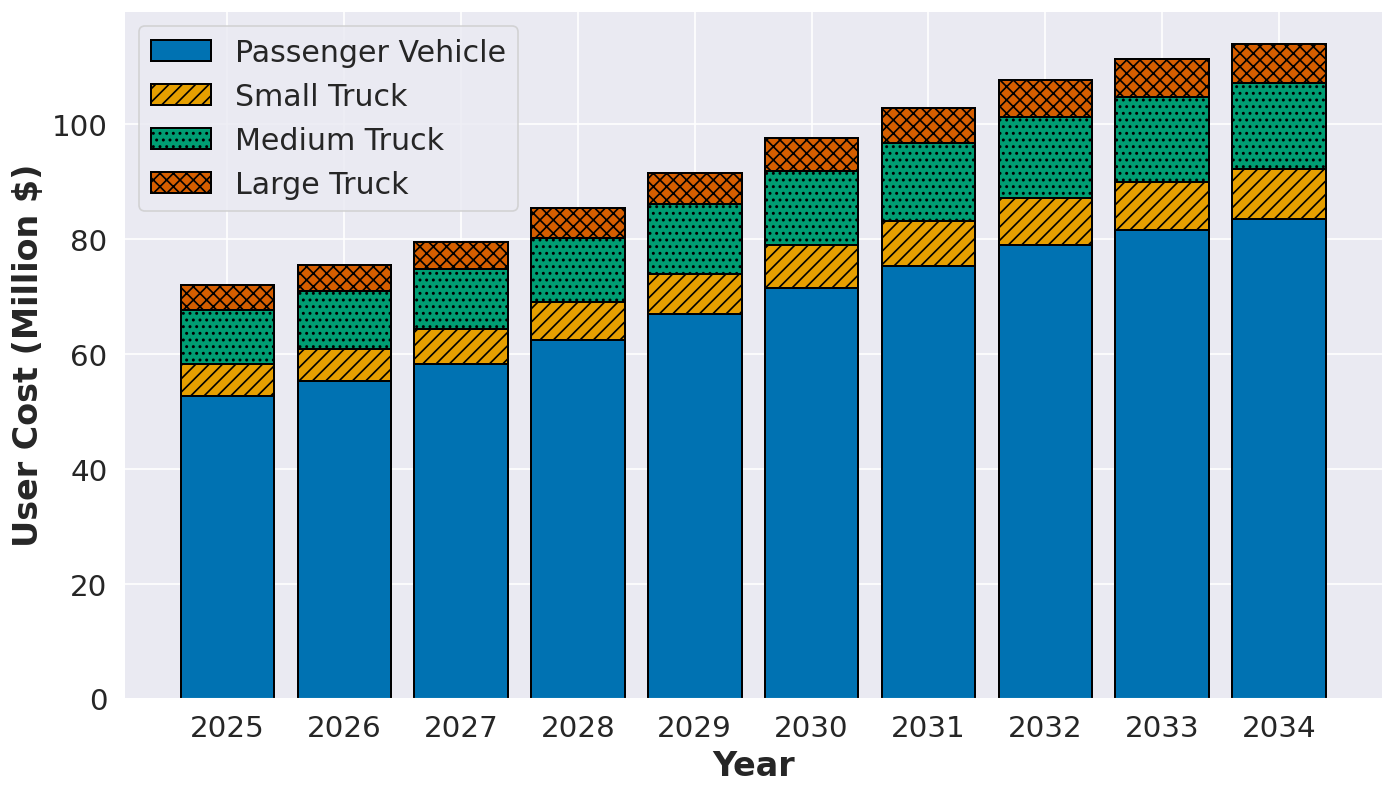

In [ ]:
years = list(range(2025, 2035))
vehicle_types = ["Passenger Vehicle", "Small Truck", "Medium Truck", "Large Truck"]

COLORS  = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]
HATCHES = ['', '///', '...', 'xxx']

annual_costs = {
    veh: [
        filtered_df[f"Cost_{veh}_{year}"].sum() / 1e6
        for year in years
    ]
    for veh in vehicle_types
}

plt.figure()
bottom = np.zeros(len(years))
for i, veh in enumerate(vehicle_types):
    costs = np.array(annual_costs[veh])
    plt.bar(
        years, costs, bottom=bottom,
        label=veh,
        color=COLORS[i],
        hatch=HATCHES[i],
        edgecolor="black",
        linewidth=1.2
    )
    bottom += costs

ax = plt.gca()
plt.xlabel("Year", fontsize=20, fontweight="bold")
plt.ylabel("User Cost (Million $)", fontsize=20, fontweight="bold")
plt.xticks(years, rotation=0)
plt.legend(frameon=True, fontsize=18)
plt.tight_layout()
plt.show()

## 12. Agency Cost from MnDOT CHIP Program – Fig. 7

Annual agency costs aggregated from the MnDOT Data Program sheet.

Total Cost per Year:
Year
2025    422,929,321.65 dollars
2026    304,759,287.88 dollars
2027    443,289,060.40 dollars
2028    260,148,677.00 dollars
2029    452,006,722.10 dollars
2030    407,883,670.96 dollars
2031    462,251,668.68 dollars
2032    400,015,357.98 dollars
2033    557,789,510.99 dollars
2034    425,358,032.77 dollars


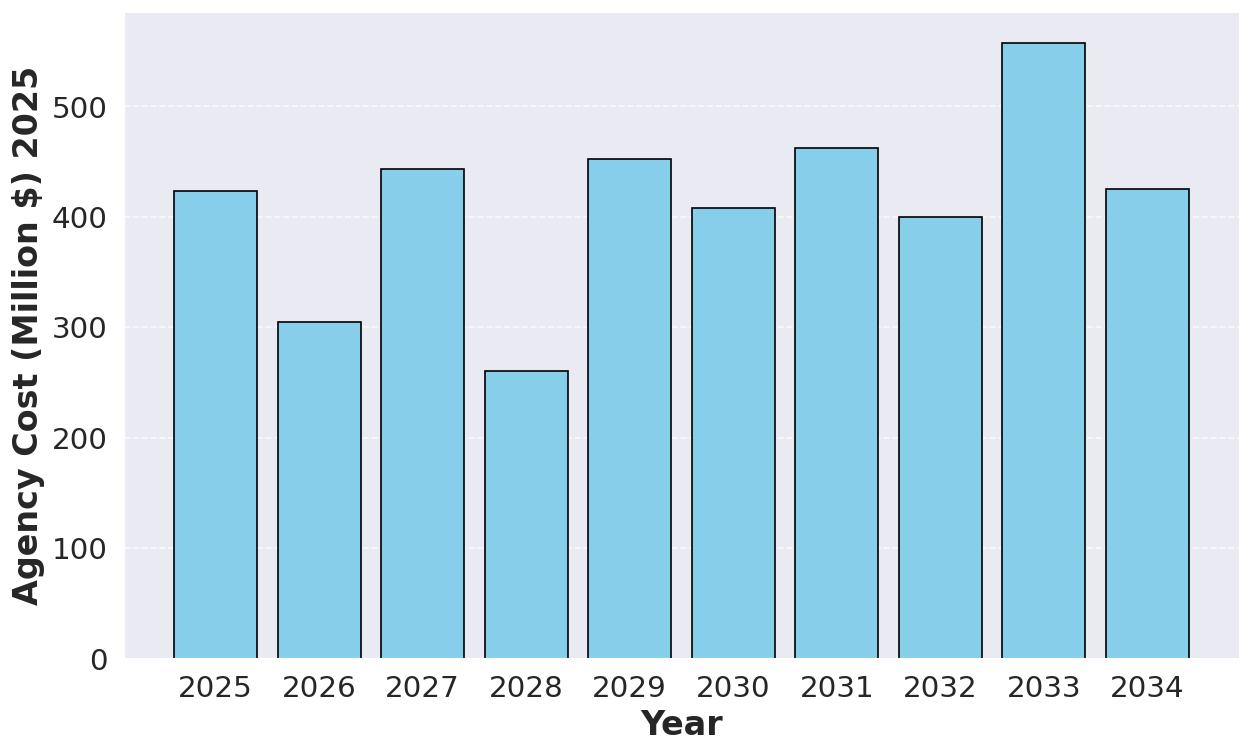

In [ ]:
# Agency cost — reads the 'Data Program' sheet (different from CHIP sheet used above)
# Define the directory path and file name
directory_path = r""
file_name = "mndot_dummy.xlsx"
file_path = os.path.join(directory_path, file_name)

# Read the "Data Program" sheet from the Excel file
df = pd.read_excel(file_path, sheet_name="Data Program")

# Trim column names to avoid issues with extra spaces
df.columns = df.columns.str.strip()

# Activities to include only for flexible pavement
valid_activities = [
    "BAB_Constr_Urban", "BAB_Constr_Rural", "Medium_Mill_Overlay", "Thin_Mill_Overlay",
    "Thick_Mill_Overlay", "Thick_Overlay", "Thin_Overlay", "Medium_Overlay",
    "Micro_Surfacing", "Reclaim_Overlay", "Nova_Chip_UTBWC", "CIR & Medium OL"]


# Filter the dataframe to only include valid activities
filtered_df = df[df["Activity"].isin(valid_activities)].copy()

# Further filter data for the years 2024 to 2035
filtered_df = filtered_df[filtered_df["Year"].between(2025, 2034)]


# Sum and round
cost_per_year = (
    filtered_df
    .groupby("Year")["Cost"]
    .sum()
    .round(2)
)


formatted = cost_per_year.map(lambda x: f"{x:,.2f} dollars")

# Print it
print("Total Cost per Year:")
print(formatted.to_string())


# Plot the results
plt.figure()
plt.bar(cost_per_year.index, cost_per_year.values / 1e6, color='skyblue', edgecolor="black")
#plt.xlabel("Year")
plt.ylabel("Agency Cost (Million $) 2025", fontsize=20, fontweight="bold")
plt.xlabel("Year", fontsize=20, fontweight="bold")
plt.xticks(cost_per_year.index)

plt.grid(axis="x", linestyle="")  # Remove vertical grid lines
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Keep only horizontal dashed lines

plt.show()